# EDA-02: Distinct Values (DV) Analysis

For each column in each dataset, we plot the **distribution of row counts across distinct values**:

- x-axis: number of rows sharing a distinct value
- y-axis: number of distinct values with that row count

Example: x=1, y=10 000 → 10 000 distinct values appear exactly once (singletons).  
List-valued columns (e.g. FEVER `evidence`) are skipped automatically.

In [1]:
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from llm_sql_phc_eval.datasets import load_datasets

DATA_DIR = Path("/Users/owhite/dev/whitechno-github/llm-sql-phc-databases")
datasets = load_datasets(DATA_DIR)
movies, products, beer, pdmx, fever, squad, bird = (
    datasets[k] for k in ("Movies", "Products", "Beer", "PDMX", "FEVER", "SQuAD", "BIRD")
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

print("Loaded:", {k: len(v) for k, v in datasets.items()})


Loaded: {'Movies': 15000, 'Products': 14890, 'Beer': 28479, 'PDMX': 10000, 'FEVER': 145449, 'SQuAD': 87599, 'BIRD': 15000}


## Helper

In [2]:
def _is_hashable_col(series, n_sample=200):
    """Return False if the series contains list or dict values (pre-check to avoid hangs)."""
    for v in series.dropna().iloc[:n_sample]:
        if isinstance(v, (list, dict)):
            return False
    return True


def plot_dv_distributions(df, name, ncols=4, figsize_per_cell=(4.5, 3.0)):
    """
    For each hashable column, plot the frequency-of-frequencies distribution:
      x = number of rows sharing a distinct value
      y = number of distinct values with that row count

    Columns with list/dict values are skipped.
    """
    col_data = []
    for col in df.columns:
        if not _is_hashable_col(df[col]):
            continue
        vc = df[col].value_counts()
        col_data.append((col, vc))

    n = len(col_data)
    nrows = math.ceil(n / ncols)
    fw, fh = figsize_per_cell
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * fw, nrows * fh), squeeze=False)
    axes = axes.flatten()

    for i, (col, vc) in enumerate(col_data):
        ax = axes[i]
        fd = vc.value_counts().sort_index()  # freq-of-freqs
        n_distinct = len(vc)
        use_logx = int(vc.max()) > 100

        if len(fd) <= 50:
            # sparse enough for exact lollipop chart
            ax.vlines(fd.index, 0, fd.values, lw=1.5, color="steelblue", alpha=0.8)
            ax.scatter(fd.index, fd.values, s=25, color="steelblue", zorder=3)
            if use_logx:
                ax.set_xscale("log")
        else:
            # many distinct freq levels — bin into histogram
            raw = vc.values
            bins = (np.logspace(np.log10(raw.min()), np.log10(raw.max() + 1), 30)
                    if use_logx else 30)
            ax.hist(raw, bins=bins, color="steelblue", alpha=0.85)
            if use_logx:
                ax.set_xscale("log")

        ax.set_title(f"{col}  [{n_distinct:,} dv]", fontsize=8)
        ax.set_xlabel("rows / value", fontsize=7)
        ax.set_ylabel("# distinct values", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.set_ylim(bottom=0)
        ax.grid(axis="y", alpha=0.3)

    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    fig.suptitle(f"{name}  ({len(df):,} rows)", fontsize=12)
    plt.tight_layout()
    plt.show()


## Combined DV stats

,n_cols,total_distinct,avg_singleton_pct,max_freq
dataset,,,,
Movies,8,16938,16.6,11266
Products,8,56100,60.0,13591
Beer,9,35762,20.4,13229
PDMX,55,92530,41.4,10000
FEVER,4,280999,48.9,109810
SQuAD,3,171380,63.1,233
BIRD,4,30449,49.6,41


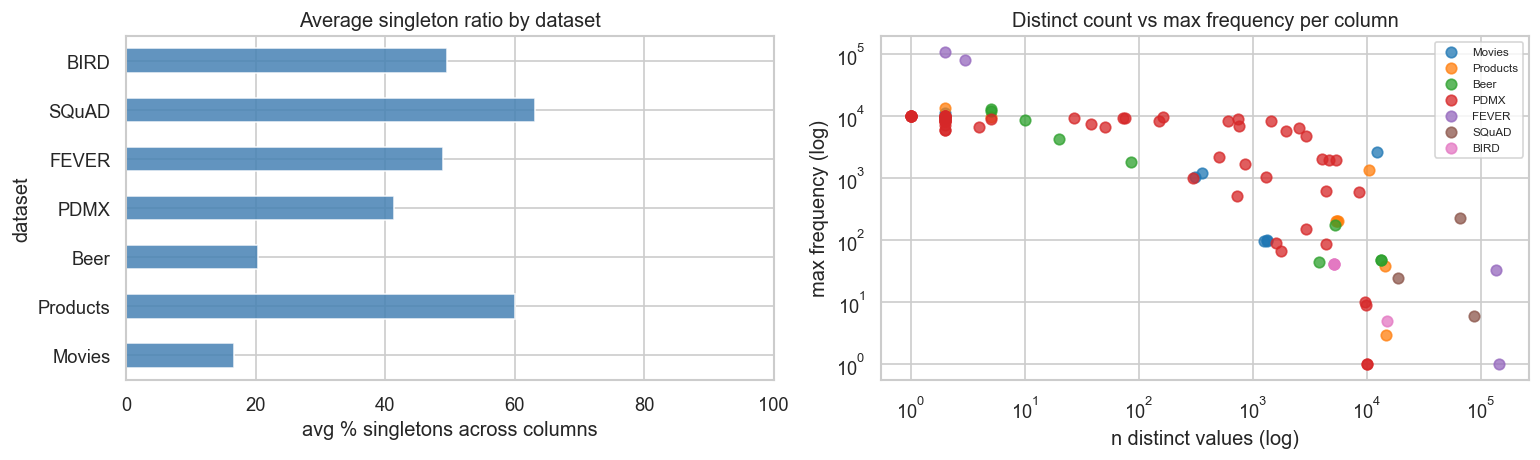

In [3]:
# Per-column DV stats across all datasets
rows = []
for ds_name, df in datasets.items():
    for col in df.columns:
        if not _is_hashable_col(df[col]):
            continue
        vc = df[col].value_counts()
        n_distinct = len(vc)
        singletons = int((vc == 1).sum())
        rows.append({
            "dataset":       ds_name,
            "column":        col,
            "n_distinct":    n_distinct,
            "singletons":    singletons,
            "singleton_pct": round(singletons / n_distinct * 100, 1) if n_distinct else 0.0,
            "max_freq":      int(vc.max()),
            "median_freq":   round(float(vc.median()), 1),
        })

dv_stats = pd.DataFrame(rows)

# Dataset-level summary
summary = (
    dv_stats.groupby("dataset", sort=False)
    .agg(
        n_cols=("column", "count"),
        total_distinct=("n_distinct", "sum"),
        avg_singleton_pct=("singleton_pct", "mean"),
        max_freq=("max_freq", "max"),
    )
    .round(1)
    .loc[list(datasets.keys())]
)
display(summary)

# Overview plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# left: avg singleton % per dataset
summary["avg_singleton_pct"].plot.barh(ax=axes[0], color="steelblue", alpha=0.85)
axes[0].set_xlabel("avg % singletons across columns")
axes[0].set_title("Average singleton ratio by dataset")
axes[0].set_xlim(0, 100)

# right: n_distinct vs max_freq scatter (one point per column)
tab10 = plt.cm.tab10.colors
ds_order = list(datasets.keys())
for ds_name, grp in dv_stats.groupby("dataset", sort=False):
    axes[1].scatter(grp["n_distinct"], grp["max_freq"],
                    color=tab10[ds_order.index(ds_name)], label=ds_name,
                    alpha=0.75, s=40)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlabel("n distinct values (log)")
axes[1].set_ylabel("max frequency (log)")
axes[1].set_title("Distinct count vs max frequency per column")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()


## Movies

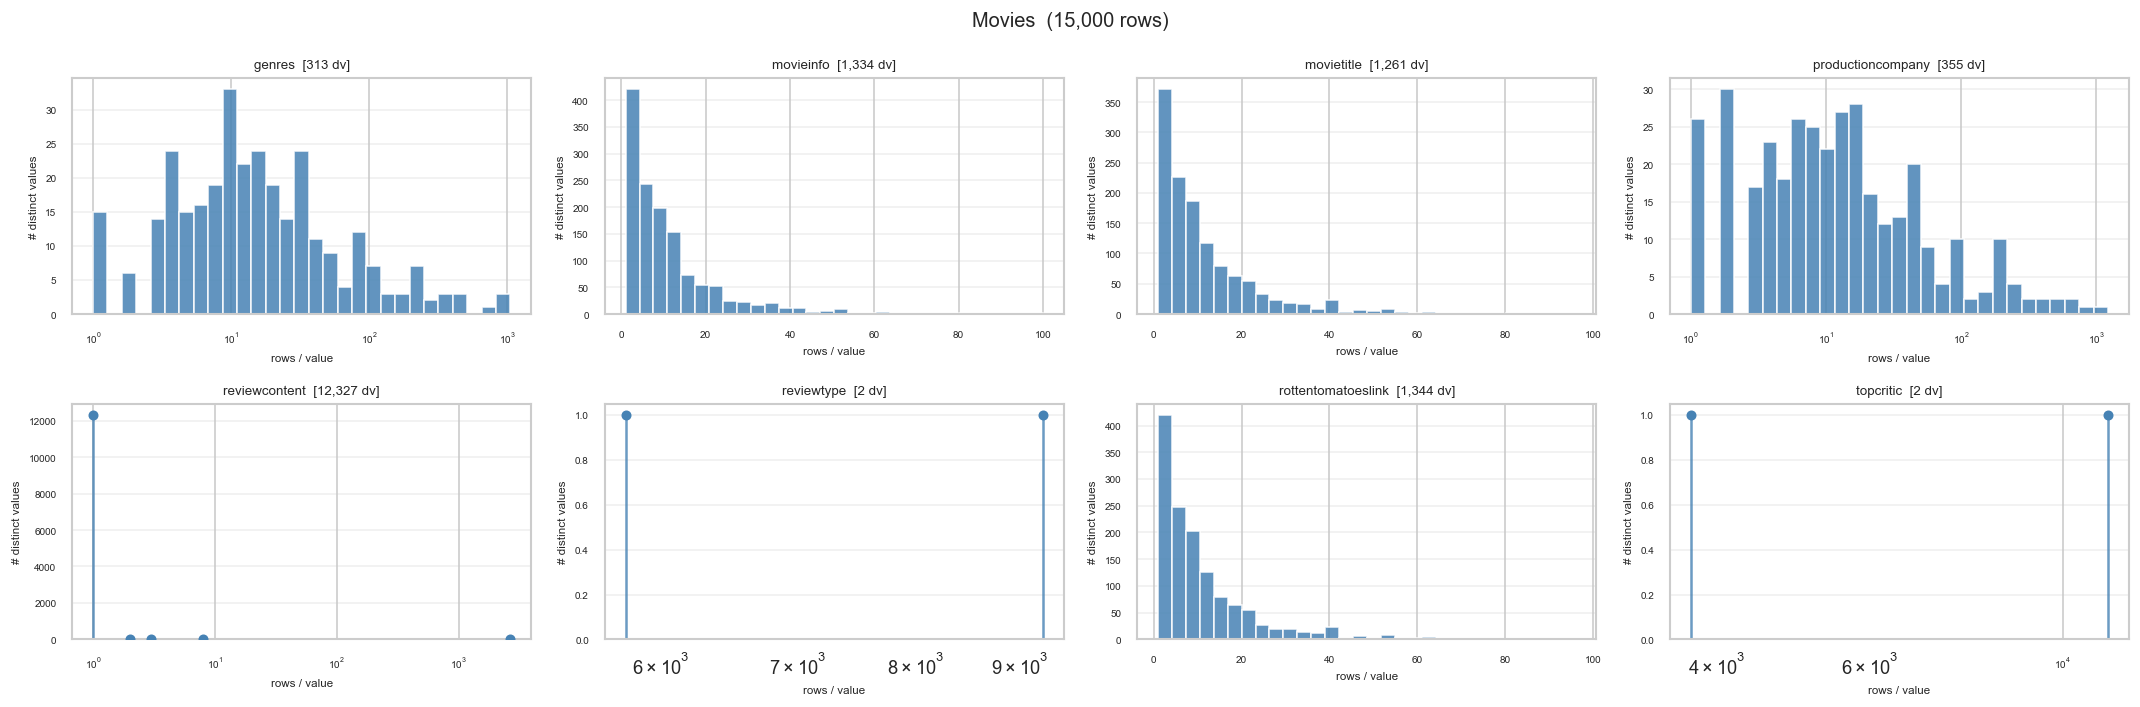

In [4]:
plot_dv_distributions(movies, "Movies")

## Products

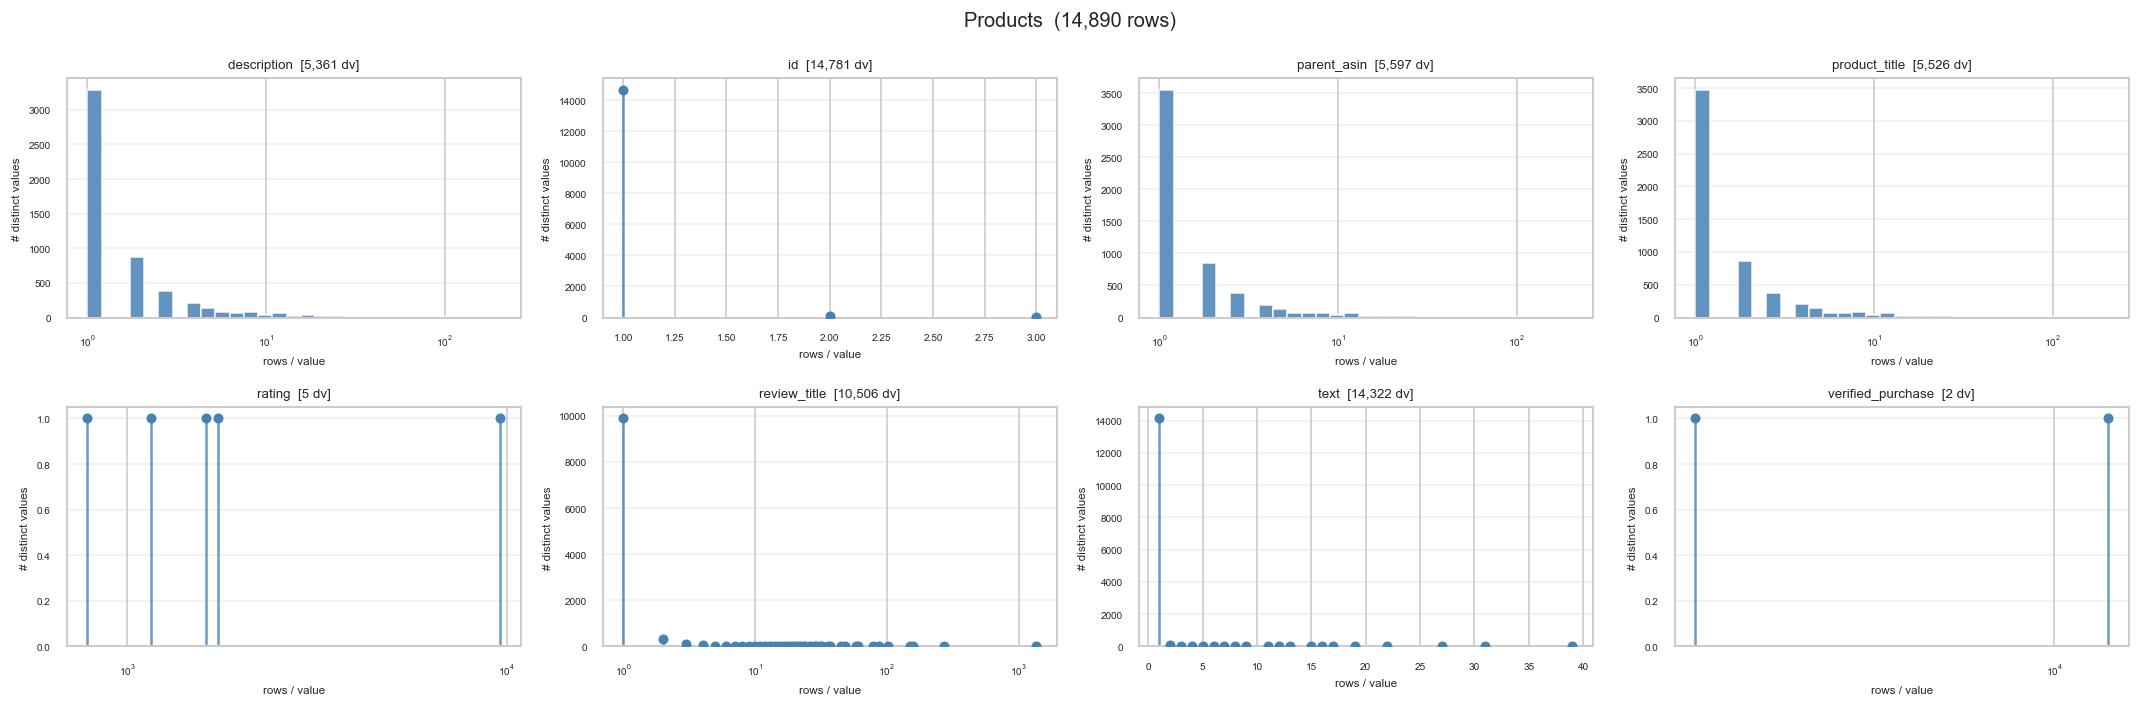

In [5]:
plot_dv_distributions(products, "Products")

## Beer

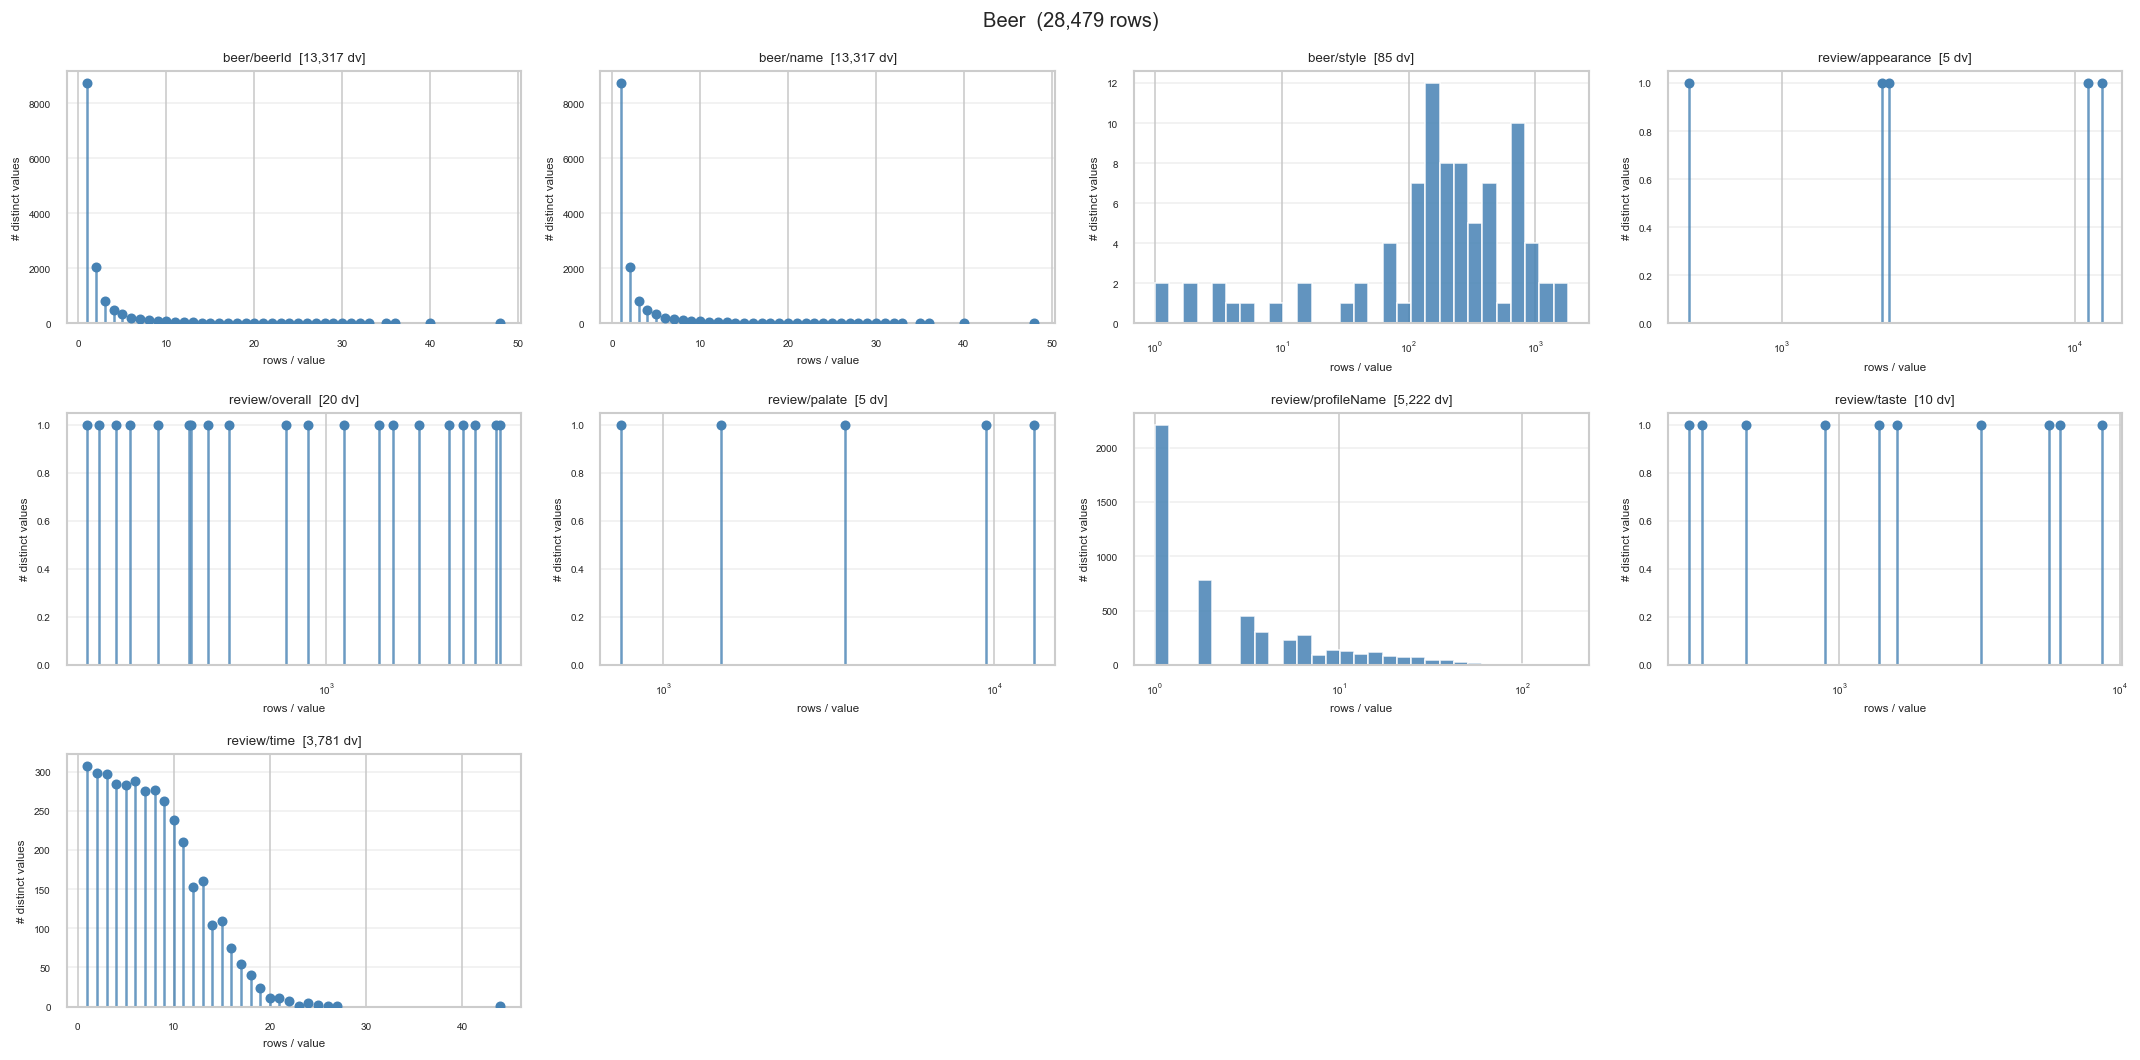

In [6]:
plot_dv_distributions(beer, "Beer")

## PDMX

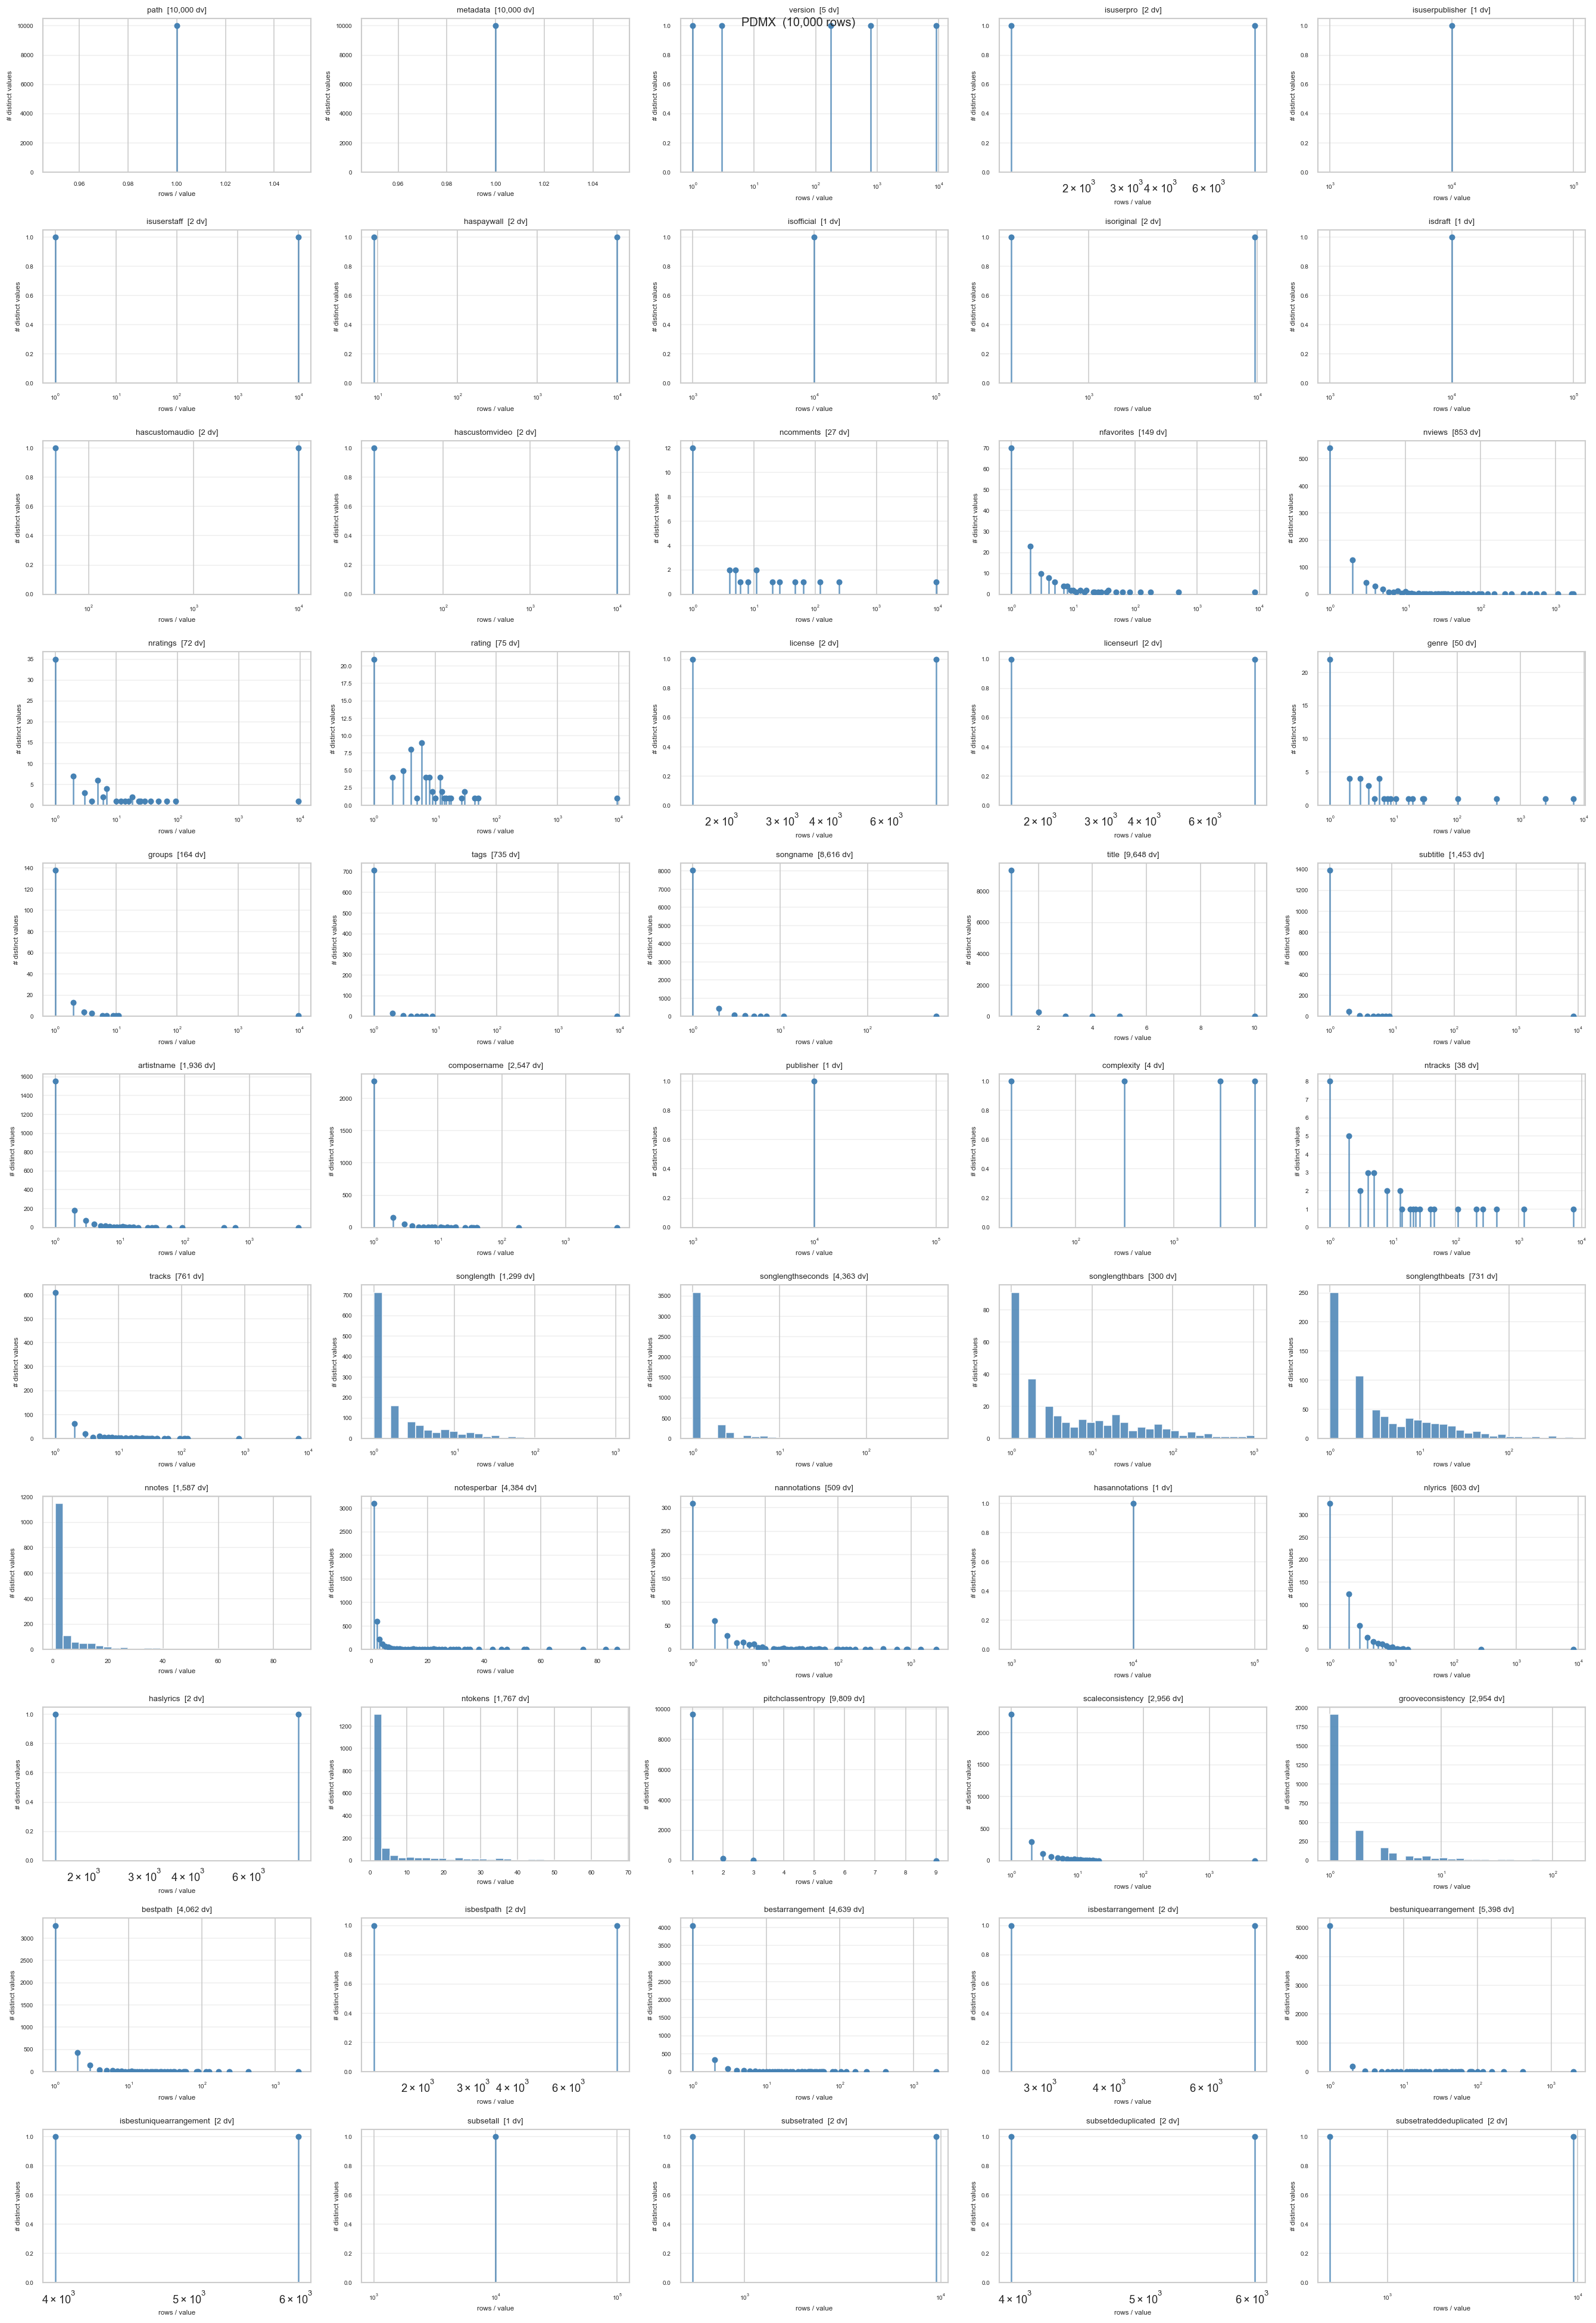

In [7]:
plot_dv_distributions(pdmx, "PDMX", ncols=5)

## FEVER

Note: list-valued `evidence` column is skipped.

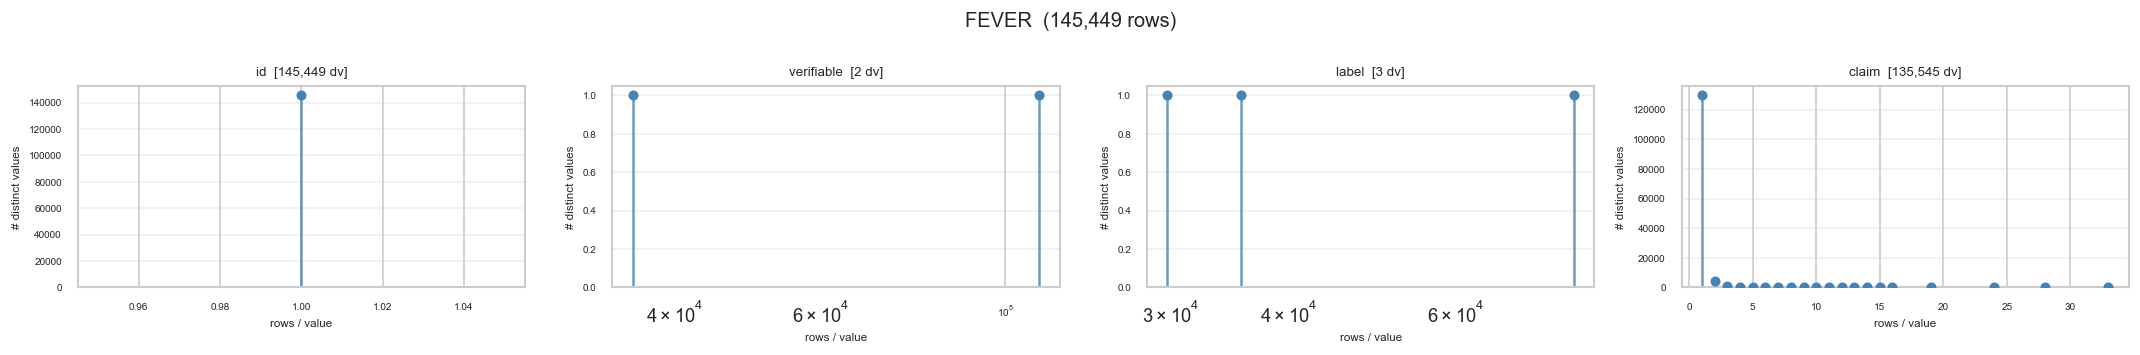

In [8]:
plot_dv_distributions(fever, "FEVER")

## SQuAD

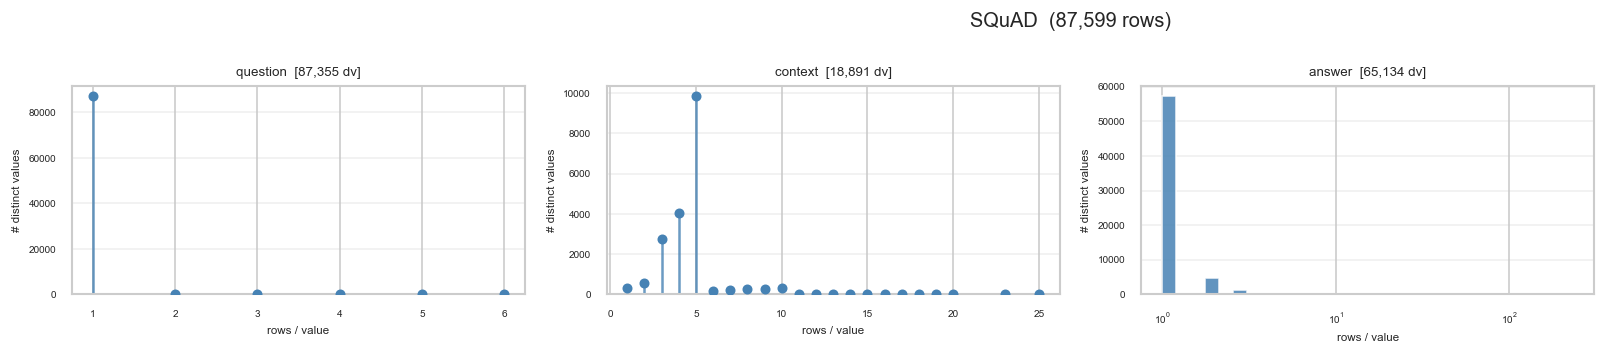

In [9]:
plot_dv_distributions(squad, "SQuAD")

## BIRD

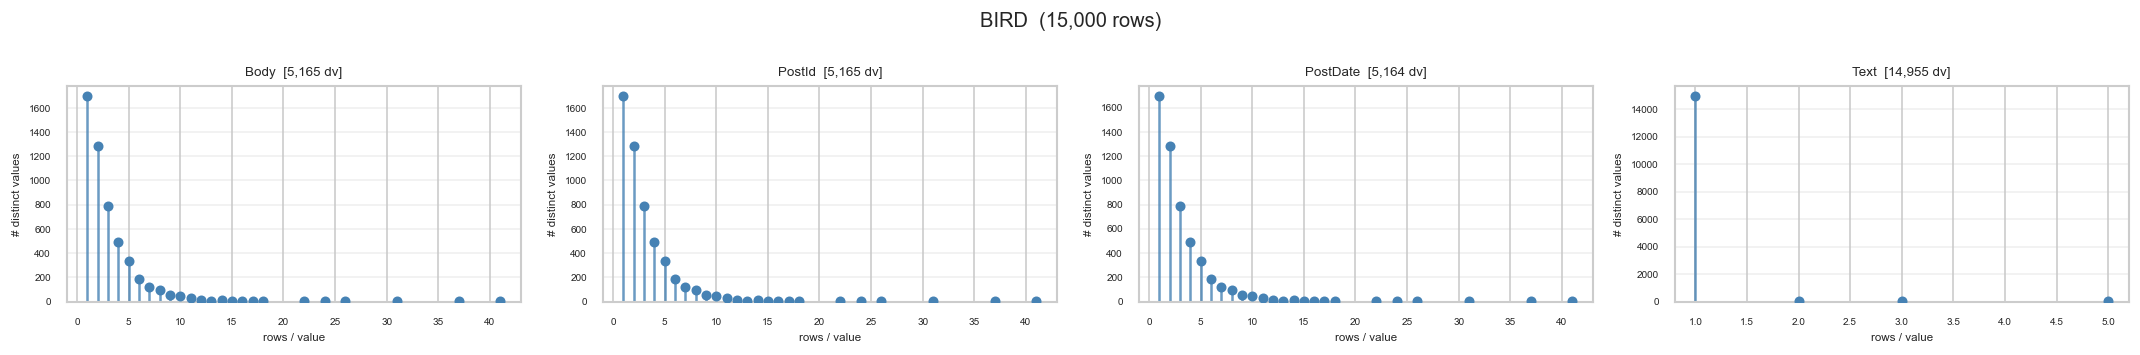

In [10]:
plot_dv_distributions(bird, "BIRD")